# SCS 3546: Deep Learning
> Assignment 1: Deep Learning Using Keras

### Your name & student number:

<pre> Cameron Turner </pre>

<pre> X606793 </pre>

## Assignment Description

In this assignment you will demonstrate your ability to:

- Train a neural network using Keras to solve a regression problem.

- Perform sensible data preprocessing.

- Experiment with hyperparemter tuning and different model architectures to achieve best performance.



### Grade Allocation

**15 points total**

- Part 1: 4 Marks
- Part 2: 9 Marks
- Clarity: 2 Marks

The marks for clarity are awarded for code documentation and how well you explained/supported your answers, including the use of visualizations where appropriate.

In [1]:
# OPTIONAL : For model evaluation and for those who choose to use the KerasRegressor from keras.wrappers, you would need to install tensorflow 2.12 or 2.11.another option is to use the scikeras.
# please note that you may have many options and the below libraries are just meant to help you and to provide options

#!pip install tensorflow==2.12
#!pip install tensorflow
#from keras.wrappers.scikit_learn import KerasRegressor

# Already done!

#!pip install scikeras
#from scikeras.wrappers import KerasClassifier, KerasRegressor


In [2]:
# Import Tensorflow libraries.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from keras.models import Sequential

# Import Sklearn libraries.

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import data science and visualization libraries.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Turn off warnings.

import warnings
warnings.filterwarnings("ignore")



# Preamble

### Hyperparameters

A hyperparameter is a parameter whose value is set before the learning process begins.

Some important Neural Networks hyperparameters include:

- number of hidden layers
- number of neurons
- learning rate
- activation function
- optimizer settings

Hyperparameters are crucial to the performance, speed, and quality of the machine learning models.

Through Hyper parameter optimization, we find a tuple (best combination) of hyperparameters that yields an optimal model which minimizes a predefined loss function on given test data.

Important hyperparameters that could be tuned include:

- num_hidden_layers
- neurons_per_layer
- dropout_rate
- activation
- optimizer
- learning_rate
- batch_size

### Loss Function

- MSE (Mean Squared Error) is used as the score/loss function that will be minimized for hyperparameter optimization.
- In this assignment, we are going to use Cross-Validation to calculate the score (MSE) for a given set of hyperparameter values

- MSE is a desirable metric because by taking the square root gives us an error value we can directly understand in the context of the problem; for example, in this assignment it translates to thousands of dollars

- Note: Your results may vary given the stochastic nature of the algorithm, evaluation procedure, or differences in numerical precision

## Dataset

We will be using mock data for this assignment. the outcome is the sale price for some products. we have created 13 features to predict the sale price.

- import provided mock data into your notebook.

- You are **not** expected to perform Exploratory Data Analysis (EDA) on this dataset.

- For the purpose of this assignment, your model's performance is not an important factor by itself - that is how far your sale price prediction is. The important factor is the changes that you observe when changing model architectures.

- The information that follow are meant to be optional and to help you get familiar with the data. Your efforts on this assignment should focus on **model training and hyperparameter tuning**, not on EDA.


# Assignment Start
***

- Please follow all instructions carefully.

- Use MSE (Mean Squared Error) as the score/loss function that will be minimized during optimization.








#Data Import

The code below imports the data for you as dataframe, then you may need to convert it to numpy arrays.  

In [3]:
# mount the colab
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Use this to see the contents of the directory to find the correct file location.

#import os
#os.listdir('/content/drive/MyDrive')

In [5]:
# Load the training and test data from the drive.
# As training data will be further divided into training and validation data,
# use "full" to indicate that this is the full training dataset.

X_train_full = pd.read_csv("/content/drive/MyDrive/X_train.csv")
y_train_full = pd.read_csv("/content/drive/MyDrive/y_train.csv")

X_test  = pd.read_csv("/content/drive/MyDrive/X_test.csv")
y_test  = pd.read_csv("/content/drive/MyDrive/y_test.csv")


In [6]:
# Take a look at example targets.

y_train_full.head()

,Unnamed: 0,0
0,0,15.2
1,1,42.3
2,2,50.0
3,3,21.1
4,4,17.7


In [7]:
# Take a look at the example features.

X_train_full.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


In [8]:
# Take a look at the total number of rows and columns (features).

X_train_full.shape

(404, 14)

In [9]:
# Examine the columns.

X_train_full.columns

Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12'],
      dtype='object')

In [10]:
# Rename the columns to make merging easier.

X_train_full.rename(columns={
    'Unnamed: 0': 'ID'
}, inplace=True)

y_train_full.rename(columns={
    'Unnamed: 0': 'ID'
}, inplace=True)

# Create a full data table of training features and targets based on the ID
# in case we need a dataframe with both training features and targets.

data_full = X_train_full.merge(y_train_full, on="ID")


In [11]:
# Do the same for the test data.

# Rename the columns to make merging easier.

X_test.rename(columns={
    'Unnamed: 0': 'ID'
}, inplace=True)

y_test.rename(columns={
    'Unnamed: 0': 'ID'
}, inplace=True)

# Create a full data table of test features and targets based on the ID
# in case we need a dataframe with both test features and targets.

data_test = X_test.merge(y_test, on="ID")


In [12]:
# Ensure that everything looks ok.

data_full.head()

,ID,0_x,1,2,3,4,5,6,7,8,9,10,11,12,0_y
0,0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


# Part 1: Impact of Changing Model Architecture

In this section, we will be comparing a simple single-layer baseline model with two other models having a different network topology.

## a) Baseline model [2 points]

Use Keras to develop a baseline neural network model that has **one single fully-connected hidden layer with the same number of neurons as input features (i.e. 13 neurons).**

Make sure to **standardize** your features (i.e. subtract mean and divide by standard deviation) before training your model. You can also perform any other data-preprocessing that you deem necessary.

- Note: No activation function is used for the output layer because it is a regression problem and we are interested in predicting numerical values directly without transformation.

- The ADAM optimization algorithm should be used to optimize mean squared error loss function.

- Plot learning curves and report on both training and validation performance.

In [13]:
# First, split the full training data into training and validation datasets.

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)


In [14]:
# Take a look at the training data (features).

X_train.head()

,ID,0,1,2,3,4,5,6,7,8,9,10,11,12
219,219,0.36920,0.0,9.90,0.0,0.544,6.567,87.3,3.6023,4.0,304.0,18.4,395.69,9.28
75,75,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93
110,110,0.26363,0.0,8.56,0.0,0.520,6.229,91.2,2.5451,5.0,384.0,20.9,391.23,15.55
113,113,0.28960,0.0,9.69,0.0,0.585,5.390,72.9,2.7986,6.0,391.0,19.2,396.90,21.14
16,16,6.53876,0.0,18.10,1.0,0.631,7.016,97.5,1.2024,24.0,666.0,20.2,392.05,2.96


In [15]:
# Take a look at the training data shape (rows, columns) after the training data / validation data split.
# It will be 303 rows from the full training set of 404 rows.

X_train.shape

(303, 14)

In [16]:
# Take a look at the training data shape (rows, columns) after the training data / validation data split.
# It will be 101 rows from the full training set of 404 rows.
#
# Therefore, the split is 303 -> Training data, 101 -> Validation data

X_valid.shape

(101, 14)

In [17]:
# Standardize the features on the entire training set:

# On all features:
#    (feature value - mean(feature)) / Standard deviation

# Alternative to using the StandardScaler:
# X_train_full = (X_train_full - X_train_full.mean(axis=0)) / X_train_full.std(axis=0)

# Use the standard scaler to scale the features.  Just fit on the training data to train
# the model.
#
# Don't fit on the valid or test data as that needs to be independent to validate
# and test the model.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

# Create the 1 layer neural net with 13 neurons using the ReLU activation function.

model = keras.Sequential([
    layers.Dense(13, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model using the Adam optimizer with a learning rate of
# the default, 0.001, telling the compiler to minimize the Minimum
# Squared Error (MSE) loss value.
#
# Monitor the compilation using the Minimum Absolute Error
# just for ease of monitoring.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Fit the model using the training features (X_train), training targets (y_train).
# Validate the model with the validation data (X_valid, y_valid).

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 28237.0371 - mae: 115.8328 - val_loss: 27750.6328 - val_mae: 109.2835
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27607.7656 - mae: 112.8449 - val_loss: 27725.3301 - val_mae: 109.1702
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26674.2852 - mae: 112.4342 - val_loss: 27702.2969 - val_mae: 109.0667
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26889.4473 - mae: 112.0606 - val_loss: 27678.2207 - val_mae: 108.9595
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25290.5918 - mae: 107.2893 - val_loss: 27655.0918 - val_mae: 108.8554
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24458.2500 - mae: 105.5295 - val_loss: 27632.2988 - val_mae: 108.7523
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26368.7031 - mae: 110.8598 - val_loss: 27609.2852 - val_mae: 108.6491
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26866.8262 - mae: 112.0490 - val_loss: 2758

In [18]:
# Now that the model has been created, evaluate the model using the test data (X_test, y_test).
# Conduct predictions on the first 3 elements of the test data.
#
# Note that model_results will contain the MSE as the first element and the MAE as the second as
# that is what it was compiled with above (in that order).

model_results = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

print(f"MSE: {model_results[0]:.3f} MAE: {model_results[1]:.3f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 878.7319 - mae: 21.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
MSE: 1312.373 MAE: 26.317


In [19]:
# Iterate over the three test cases and display the value vs what was predicted.

for i in range(3):
    print(f"Actual value: {y_test.iloc[i]['0']:.3f}, Prediction: {y_pred[i][0]:.3f}")

Actual value: 7.200, Prediction: 10.960
Actual value: 18.800, Prediction: 2.856
Actual value: 19.000, Prediction: 11.941


In [20]:
# Take a look at the dataframe for the metrics that were created from the model training.

pd.DataFrame(history.history).head()

,loss,mae,val_loss,val_mae
0,27298.835938,113.040390,27750.632812,109.283470
1,27274.119141,112.933578,27725.330078,109.170235
2,27250.314453,112.829323,27702.296875,109.066719
3,27227.019531,112.727631,27678.220703,108.959496
4,27203.185547,112.624588,27655.091797,108.855354


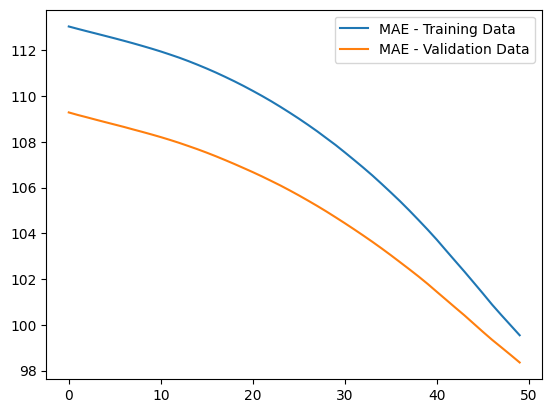

In [21]:
# Plot the Mean Absolute Error values for the model training (over the epochs).

plt.plot(history.history['mae'], label='MAE - Training Data')
plt.plot(history.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

For the Mean Absolute Error (MAE), as the model training progressed, the absolute error decreased (good!).  The training and validation data started to converge as the training progressed over the epochs indicating that the model is starting to generalize well.  The model is performing well on the validation data (data not seen before) indicating the model is learning.

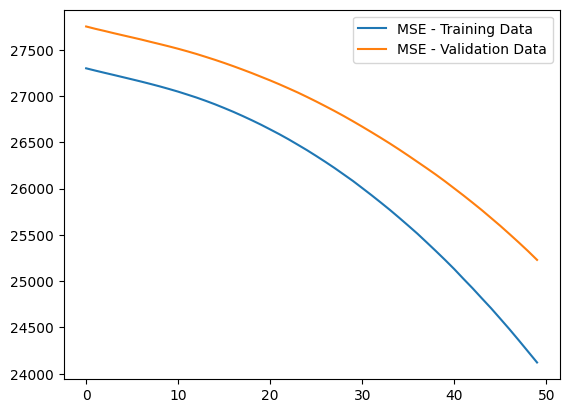

In [22]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history.history['loss'], label='MSE - Training Data')
plt.plot(history.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

Similar to the MAE, the Mean Squared Error (MSE) is also starting to decrease as model training progresses indicating that the model is learning.

In [23]:
# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

## b) Deeper Network [1 point]

Construct and evaluate a model with 2 dense layers having a smaller number of neurons (e.g. 16, 8).

In [24]:
# Clear the session.

tf.keras.backend.clear_session()

# Create the input layer.

input_ = Input(shape=X_train.shape[1:])

# Create two hidden dense layers. One with 16 neurons and another with 8 neurons.

X = Dense(16, activation="relu")(input_)
X = Dense(8, activation="relu")(X)

# Create the concatenation layer to concatenate the input and hidden layers.

X = Concatenate(axis=-1)([input_, X])

# Finally, create the output layer.

output = Dense(1)(X)

# Add the Inputs and Outputs to a model.

model_deeper = Model(inputs=[input_], outputs=[output])



In [25]:
# Output the model summary to verify the layers.

model_deeper.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        240 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 22)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         23 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 399 (1.56 KB)

 Trainable params: 399 (1.56 KB)

 Non-trainable params: 0 (0.00 B)

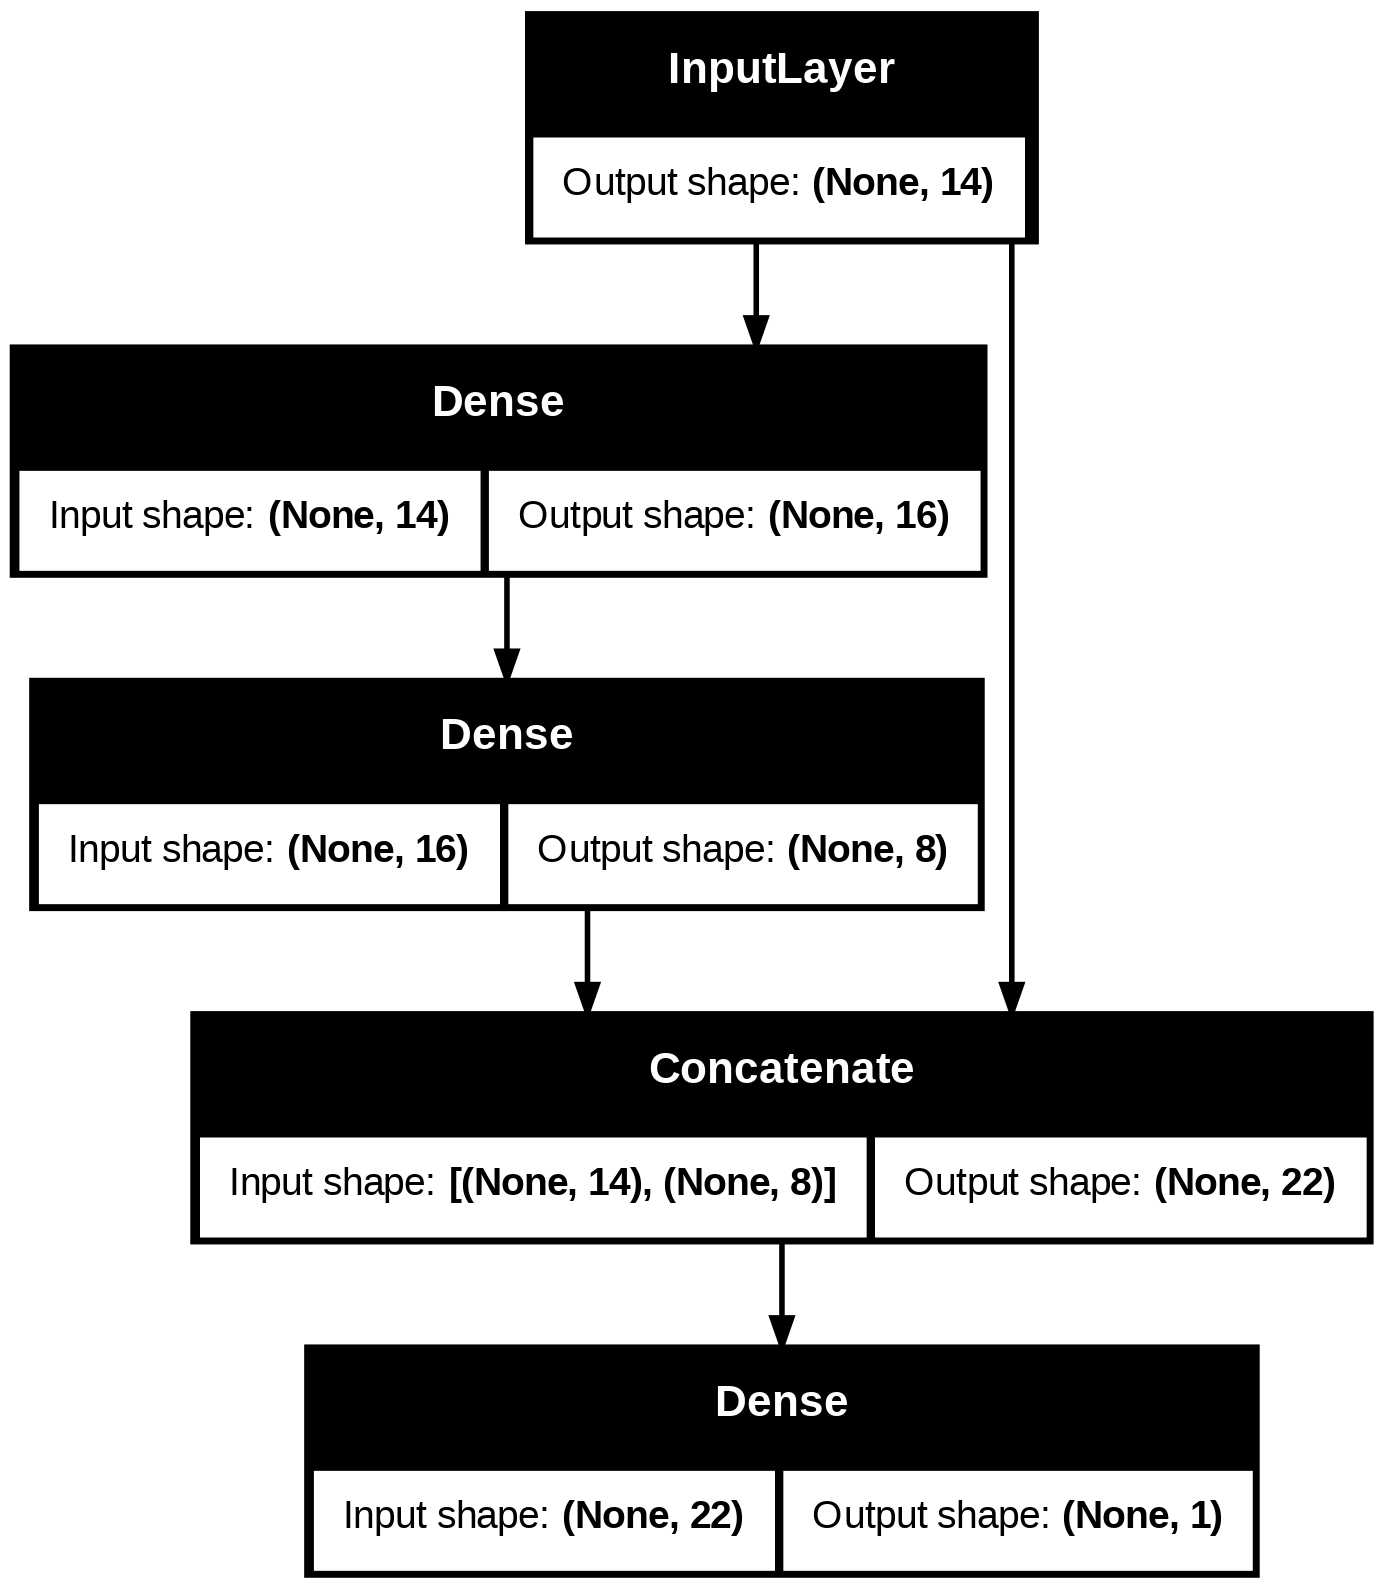

In [26]:
# Visualize the model summary from above.

keras.utils.plot_model(model_deeper, show_shapes=True)


In [27]:
# Compile the model using the Stochastic Gradient Descent (SGD) optimizer with a learning rate of
# the default, 0.001, telling the compiler to minimize the Minimum
# Squared Error (MSE) loss value.
#
# Monitor the compilation using the Minimum Absolute Error
# just for ease of monitoring.

model_deeper.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Fit the model using the training features (X_train), training targets (y_train).
# Validate the model with the validation data (X_valid, y_valid).

history_deeper = model_deeper.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_valid, y_valid),
    verbose=1)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 24868.9668 - mae: 108.0174 - val_loss: 22908.6777 - val_mae: 117.4671
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25466.3613 - mae: 113.0701 - val_loss: 21102.8262 - val_mae: 106.2209
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17702.2148 - mae: 99.1592 - val_loss: 21414.6406 - val_mae: 95.5503
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19263.0352 - mae: 97.6599 - val_loss: 26458.0996 - val_mae: 105.6782
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25646.0195 - mae: 109.6325 - val_loss: 25937.4336 - val_mae: 103.3060
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24066.8516 - mae: 102.6950 - val_loss: 25490.9922 - val_mae: 116.2102
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29985.9648 - mae: 121.9888 - val_loss: 24917.0254 - val_mae: 99.6428
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25879.0547 - mae: 105.4807 - val_loss: 24416.8

In [28]:
# Now that the model has been created, evaluate the model using the test data (X_test, y_test).
# Conduct predictions on the first 3 elements of the test data.
#
# Note that model_results will contain the MSE as the first element and the MAE as the second as
# that is what it was compiled with above (in that order).

model_results = model_deeper.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model_deeper.predict(X_new)

print(f"MSE: {model_results[0]:.3f} MAE: {model_results[1]:.3f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 309.0226 - mae: 14.0305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
MSE: 447.568 MAE: 17.475


In [29]:
# Iterate over the three test cases and display the value vs what was predicted.

for i in range(3):
    print(f"Actual value: {y_test.iloc[i]['0']:.3f}, Prediction: {y_pred[i][0]:.3f}")

Actual value: 7.200, Prediction: 10.038
Actual value: 18.800, Prediction: 18.318
Actual value: 19.000, Prediction: 21.238


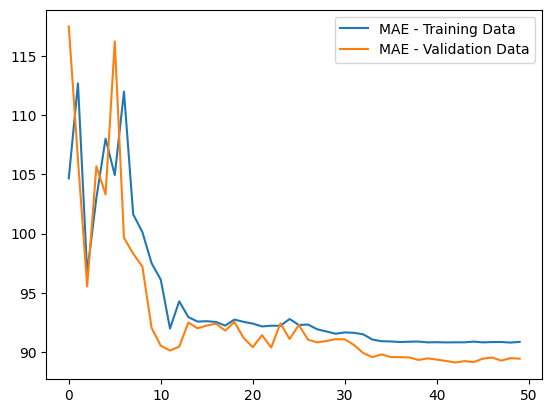

In [30]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history_deeper.history['mae'], label='MAE - Training Data')
plt.plot(history_deeper.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The MAE seems to jump all over the place in the initial stages of learning but seems to converge after 10 epochs.  This is to be expected as the gradients are transferred between multiple layers.


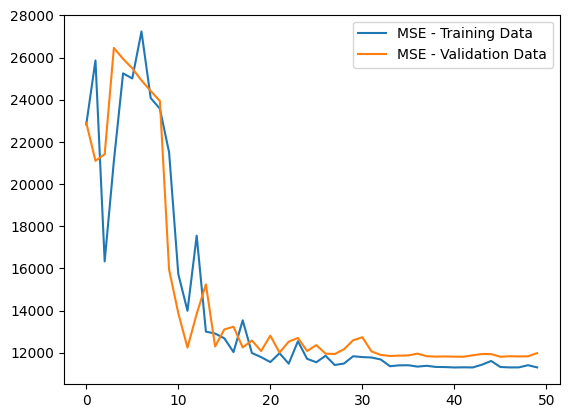

In [31]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history_deeper.history['loss'], label='MSE - Training Data')
plt.plot(history_deeper.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

Similar to MAE, the MSE seems to jump all over the place in the initial stages of learning but seems to converge after 10 epochs.

## c) Wider Network [1 point]

Construct and evaluate a wider model with more neurons (e.g. 32, 16).

In [32]:
# Clear the session.

tf.keras.backend.clear_session()

# Create the input layer.

input_ = Input(shape=X_train.shape[1:])

# Create the first branch.

branch1 = Dense(32, activation="relu")(input_)
branch1 = Dense(32, activation="relu")(branch1)

# Create the second branch.

branch2 = Dense(16, activation="relu")(input_)
branch2 = Dense(16, activation="relu")(branch2)

# Create the concatenate layer.

concan = Concatenate(axis=-1)([input_, branch1, branch2])

# Finally, create the output layer.

output = Dense(1)(concan)

# Add the Inputs and Outputs to a model.

model_wider = Model(inputs=[input_], outputs=[output])



In [33]:
# Output the model summary to verify the layers.

model_wider.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        480 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        240 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        272 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 62)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         63 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,111 (8.25 KB)

 Trainable params: 2,111 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

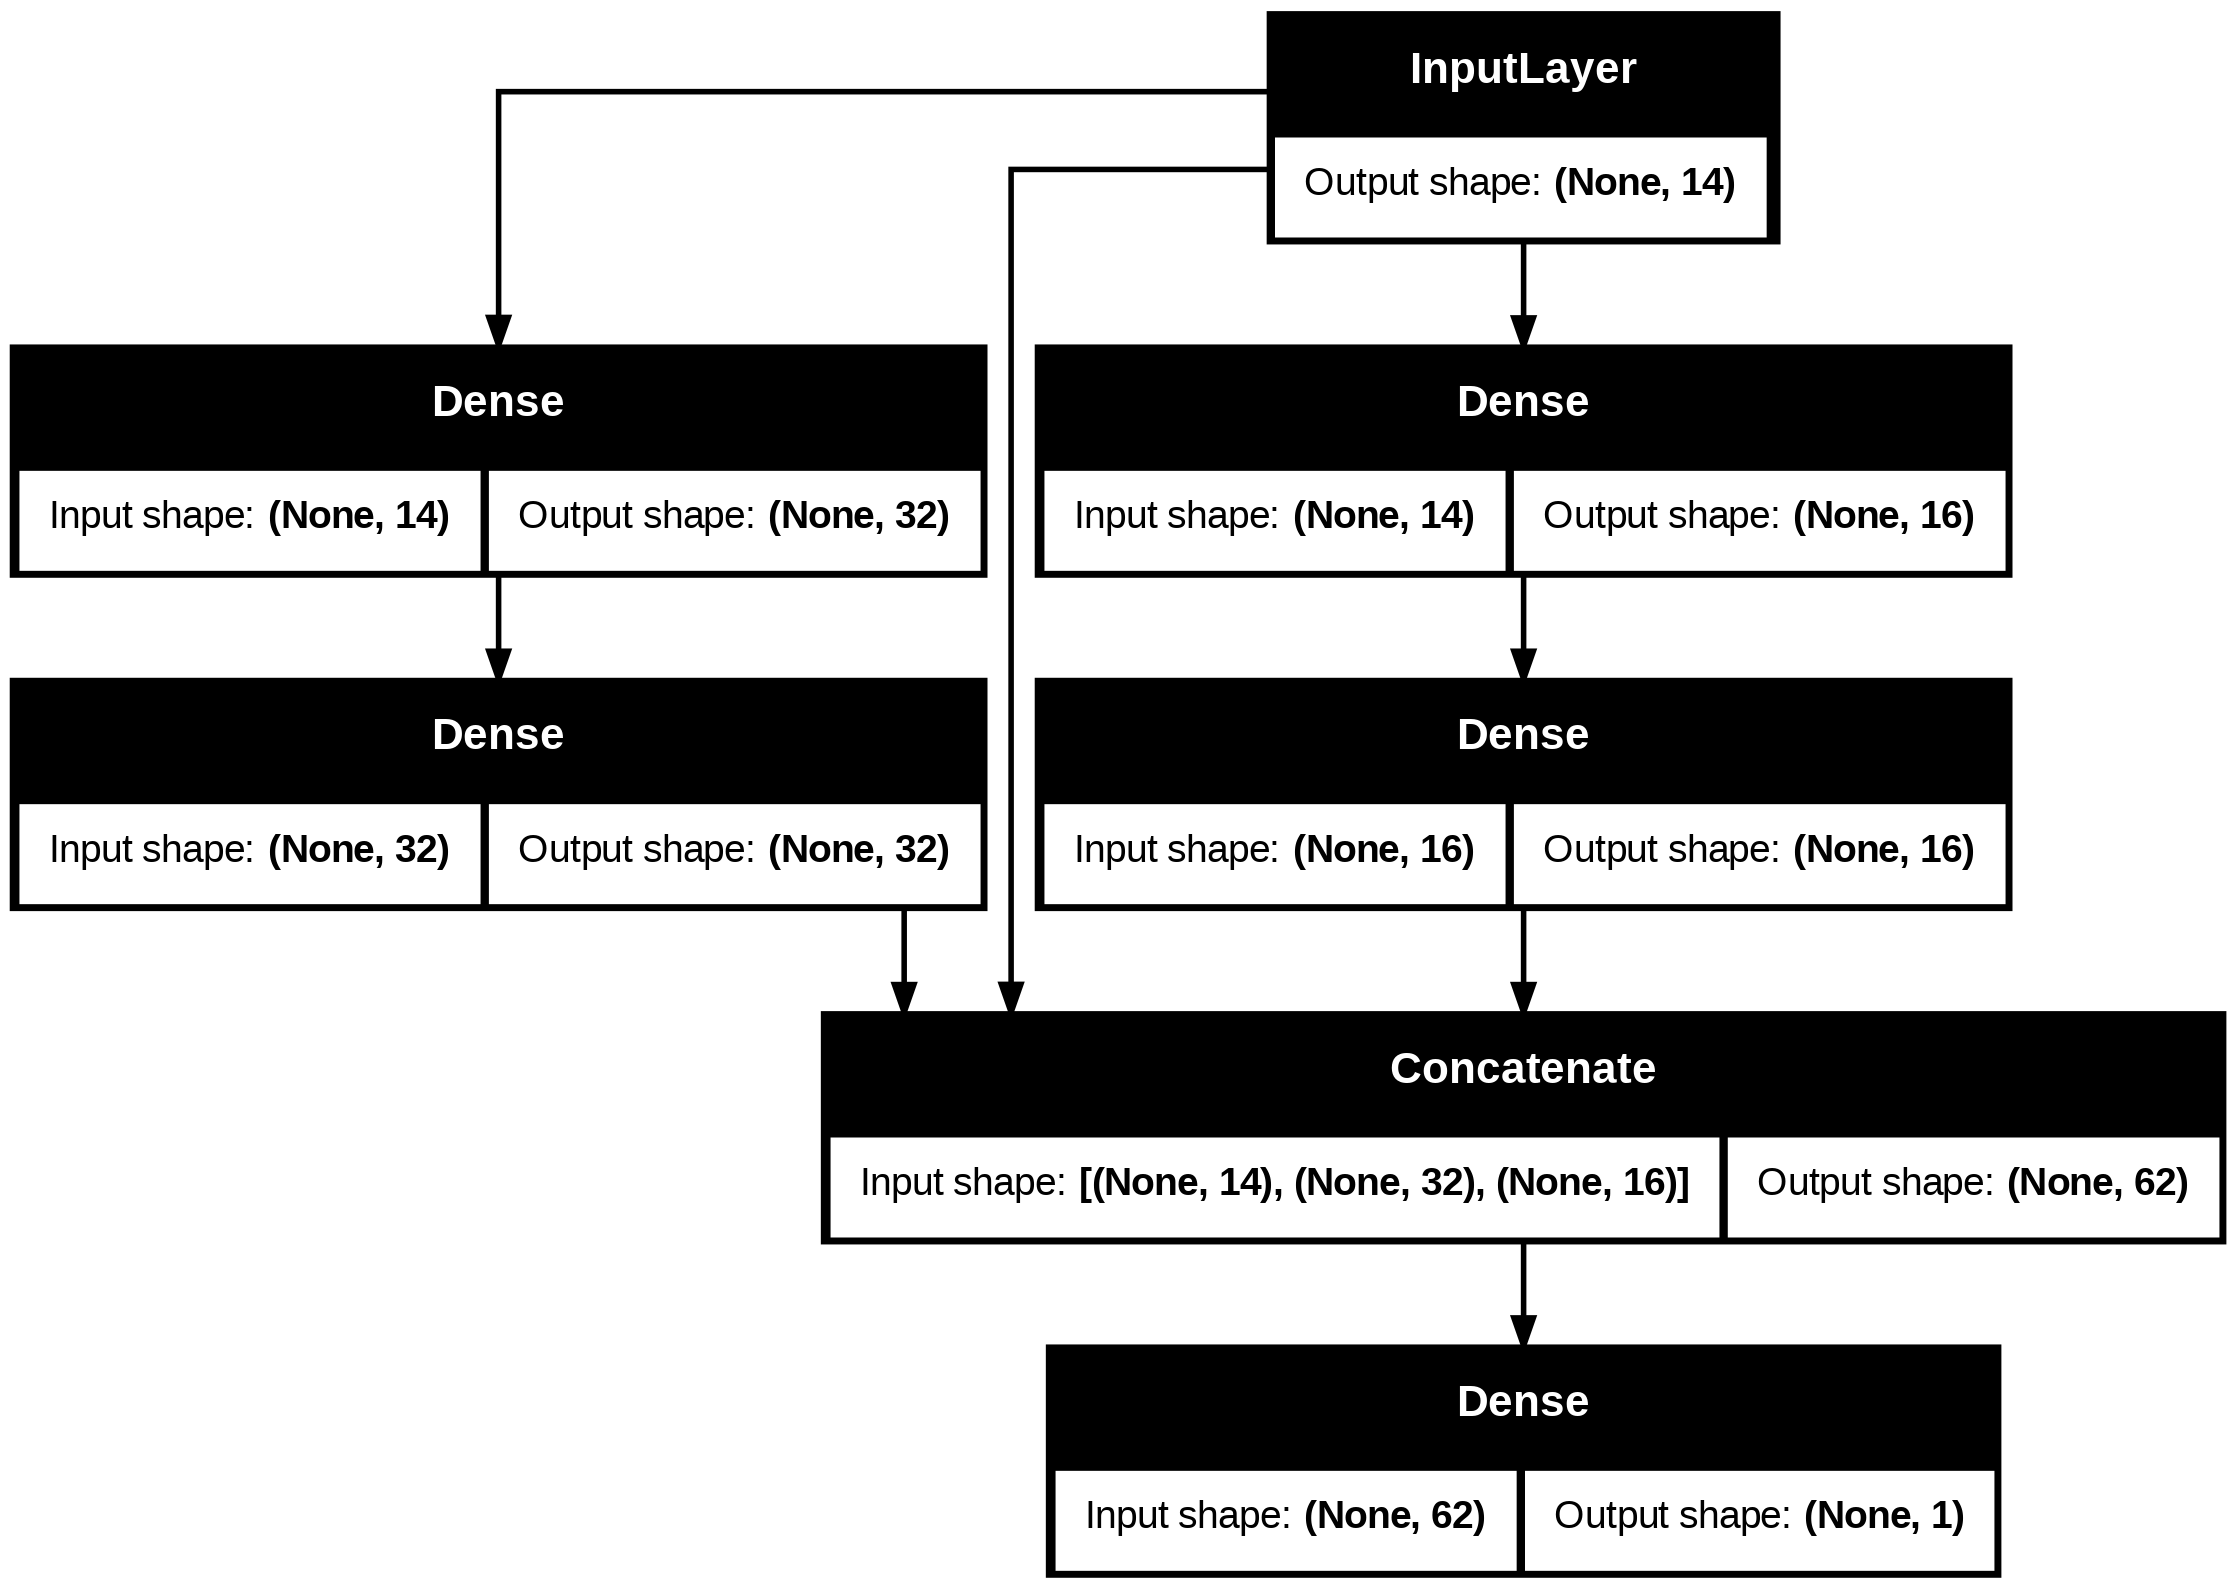

In [34]:
# Visualize the model summary from above.

keras.utils.plot_model(model_wider, show_shapes=True)


In [35]:
# Compile the model using the Adam optimizer with a learning rate of
# the default, 0.001, telling the compiler to minimize the Minimum
# Squared Error (MSE) loss value.
#
# Monitor the compilation using the Minimum Absolute Error
# just for ease of monitoring.

model_wider.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Fit the model using the training features (X_train), training targets (y_train).
# Validate the model with the validation data (X_valid, y_valid).

history_wider = model_wider.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_valid, y_valid))


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 26301.0566 - mae: 110.8064 - val_loss: 27519.0547 - val_mae: 108.2251
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 26367.8711 - mae: 108.4233 - val_loss: 27401.9355 - val_mae: 107.6864
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 27399.8242 - mae: 112.4045 - val_loss: 27261.9844 - val_mae: 107.0363
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 27296.9688 - mae: 111.6997 - val_loss: 27088.8887 - val_mae: 106.2226
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25703.0234 - mae: 107.1920 - val_loss: 26868.7188 - val_mae: 105.2183
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24596.7422 - mae: 105.1869 - val_loss: 26587.8262 - val_mae: 103.9682
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25570.5059 - mae: 106.6546 - val_loss: 26229.3145 - val_mae: 102.3708
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26081.5938 - mae: 105.8348 - val_loss:

In [36]:
# Now that the model has been created, evaluate the model using the test data (X_test, y_test).
# Conduct predictions on the first 3 elements of the test data.
#
# Note that model_results will contain the MSE as the first element and the MAE as the second as
# that is what it was compiled with above (in that order).

model_results = model_wider.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model_wider.predict(X_new)

print(f"MSE: {model_results[0]:.3f} MAE: {model_results[1]:.3f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1026.6826 - mae: 27.2131
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
MSE: 1082.122 MAE: 27.715


In [37]:
# Iterate over the three test cases and display the value vs what was predicted.

for i in range(3):
    print(f"Actual value: {y_test.iloc[i]['0']:.3f}, Prediction: {y_pred[i][0]:.3f}")

Actual value: 7.200, Prediction: 60.382
Actual value: 18.800, Prediction: 21.394
Actual value: 19.000, Prediction: 44.701


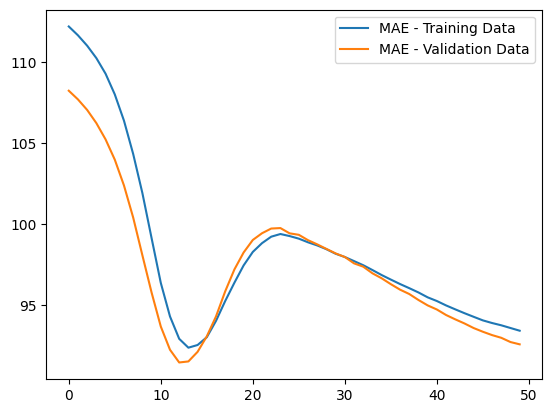

In [38]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history_wider.history['mae'], label='MAE - Training Data')
plt.plot(history_wider.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The MAE seems to decrease quickly up to 10 epochs and then increases over the next 10 before decreasing again until it gradually flattens to 50 epochs.  It is a nice, smooth graph as it has more parameters.





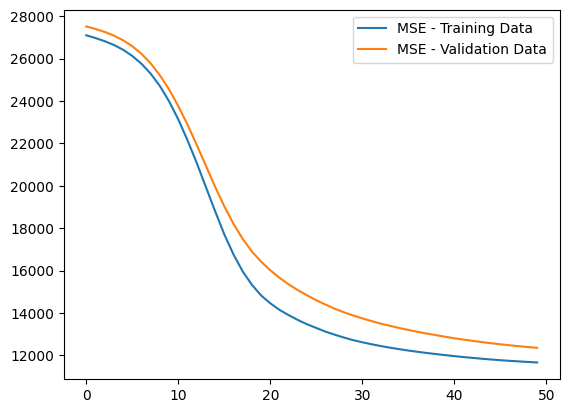

In [39]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history_wider.history['loss'], label='MSE - Training Data')
plt.plot(history_wider.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

The MSE seems to decrease quickly up to 20 epochs and then  gradually flattens to 50 epochs.  It is a nice, smooth graph as it has more parameters.


# Part 2: Hyperparameter Tuning Experiments

In the following experiments, you will evaluate and compare models trained with different hyperparameters. Please follow the specifications given for each model.

## a) Model 1 [2 points]

- 2 Dense layers:
  - The first with 64 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

In [40]:
y_train_full.head()

,ID,0
0,0,15.2
1,1,42.3
2,2,50.0
3,3,21.1
4,4,17.7


In [41]:
y_train_full.shape

(404, 2)

In [42]:
# The following is our code but 'cleaned' - see what the difference is between our code
# We don't need the predictions so just remove that. Looks like an extra step when cross-validating.

In [43]:

# Set the number of folds / splits.

the_splits = 3

# Create the cross-fold object.

kf = KFold(n_splits=the_splits, shuffle=True, random_state=42)

# Initialize the Mean Absolute Error array.

mae_scores = []

# Create the cross-validation on the training data.

for train_idx, valid_idx in kf.split(X_train_full):

    X_train, X_valid = X_train_full.iloc[train_idx], X_train_full.iloc[valid_idx]
    y_train, y_valid = y_train_full.iloc[train_idx, -1], y_train_full.iloc[valid_idx, -1]

    # Use the standard scaler to scale the features.  Just fit on the training data to train
    # the model and prevent data leakage into the model.
    #
    # Don't fit on the valid data as that needs to be independent to validate
    # and test the model.
    #
    # Don't include the test data as that would transform the data
    # multiple times in a cross-fold.

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # Create a 2 hidden layer neural net with 64 neurons in each using
    # the ReLU activation function.

    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    # Compile the model using the Adam optimizer with a learning rate of
    # the default, 0.001, telling the compiler to minimize the Minimum
    # Squared Error (MSE) loss value which is good for regression.
    #
    # Monitor the compilation using the Minimum Absolute Error
    # just for ease of monitoring and a more user-friendly way of
    # interpreting error.

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Fit the model using the training features (X_train), training targets (y_train).
    # Validate the model with the validation data (X_valid, y_valid).

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    # Validate the model, calculate the MAE for this fold
    # and store it in the array.

    y_pred = model.predict(X_valid, verbose=0)
    kfold_mae = mean_absolute_error(y_valid, y_pred)
    mae_scores.append(kfold_mae)

# Calculate the overall MAE with standard deviation from the cross-validation.
# The MAE from cross-validation is based on the MAEs collected during each
# cross-validation fold.

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

print(f"MAE from cross-validation = {mean_mae:.3f} ± {std_mae:.3f}")


MAE from cross-validation = 2.682 ± 0.030


In [44]:
data_full.head()

,ID,0_x,1,2,3,4,5,6,7,8,9,10,11,12,0_y
0,0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


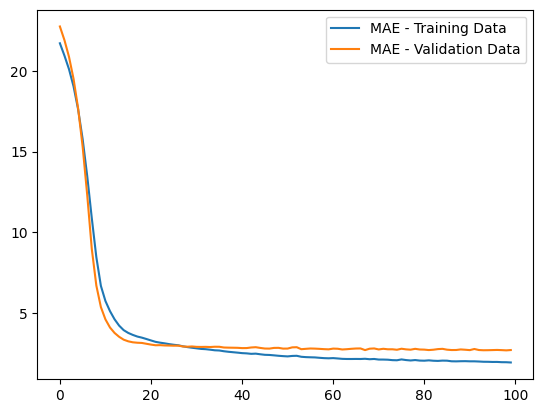

In [45]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history.history['mae'], label='MAE - Training Data')
plt.plot(history.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The training and validation MAEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge and flatten after 15 epochs.

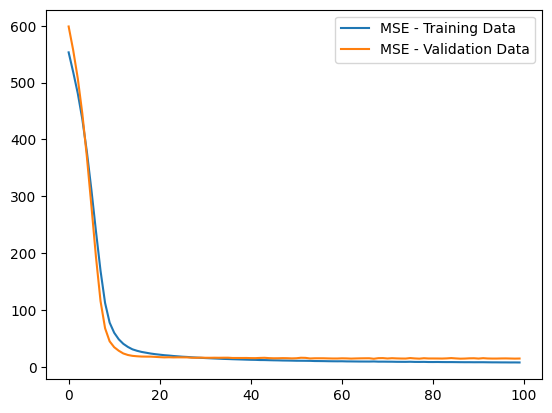

In [46]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history.history['loss'], label='MSE - Training Data')
plt.plot(history.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

The training and validation MSEs follow the same pattern as the MAEs.  They quickly drop over the first 15 epochs in the initial stages of learning and converge and flatten after 15 epochs.

## b) Model 2 [2 points]

- 2 Dense layers:
  - The first with 128 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

In [47]:
# Set the number of folds / splits.

the_splits = 3

# Create the cross-fold object.

kf = KFold(n_splits=the_splits, shuffle=True, random_state=42)

# Initialize the Mean Absolute Error array.

mae_scores = []

# Create the cross-validation on the training data.

for train_idx, valid_idx in kf.split(X_train_full):

    X_train, X_valid = X_train_full.iloc[train_idx], X_train_full.iloc[valid_idx]
    y_train, y_valid = y_train_full.iloc[train_idx, -1], y_train_full.iloc[valid_idx, -1]

    # Use the standard scaler to scale the features.  Just fit on the training data to train
    # the model and prevent data leakage into the model.
    #
    # Don't fit on the valid data as that needs to be independent to validate
    # and test the model.
    #
    # Don't include the test data as that would transform the data
    # multiple times in a cross-fold.

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # Create a 2 hidden layer neural net with 128 neurons in the first
    # hidden layer and 64 neurons in the second both using
    # the ReLU activation function.

    model = keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    # Compile the model using the Adam optimizer with a learning rate of
    # the default, 0.001, telling the compiler to minimize the Minimum
    # Squared Error (MSE) loss value which is good for regression.
    #
    # Monitor the compilation using the Minimum Absolute Error
    # just for ease of monitoring and a more user-friendly way of
    # interpreting error.

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Fit the model using the training features (X_train), training targets (y_train).
    # Validate the model with the validation data (X_valid, y_valid).

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    # Validate the model, calculate the MAE for this fold
    # and store it in the array.

    y_pred = model.predict(X_valid, verbose=0)
    kfold_mae = mean_absolute_error(y_valid, y_pred)
    mae_scores.append(kfold_mae)

# Calculate the overall MAE with standard deviation from the cross-validation.
# The MAE from cross-validation is based on the MAEs collected during each
# cross-validation fold.

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

print(f"MAE from cross-validation = {mean_mae:.3f} ± {std_mae:.3f}")


MAE from cross-validation = 2.650 ± 0.019


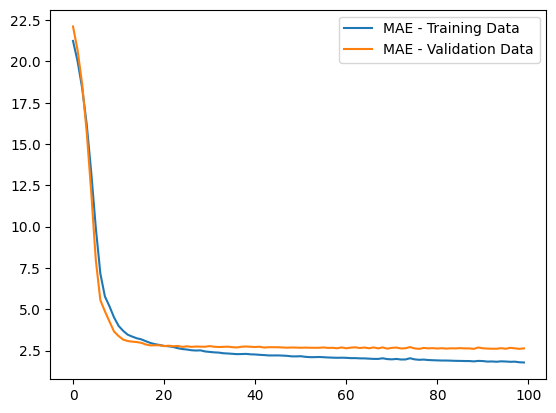

In [48]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history.history['mae'], label='MAE - Training Data')
plt.plot(history.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The training and validation MAEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge and flatten after 15 epochs.

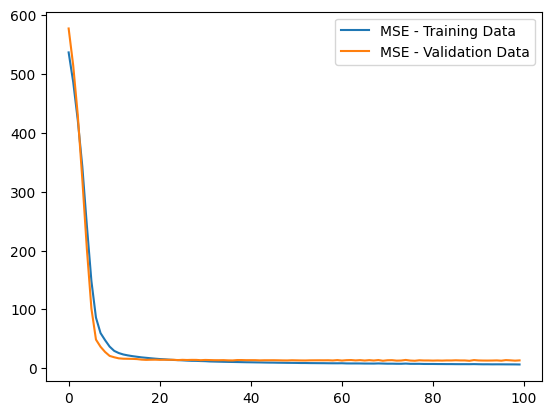

In [49]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history.history['loss'], label='MSE - Training Data')
plt.plot(history.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

The training and validation MSEs follow the same pattern as the MAEs.  They quickly drop over the first 15 epochs in the initial stages of learning and converge and flatten after 15 epochs.

## c) Model 3 [2 points]

- Same as Model 2, but use tanh activation functions instead of relu.

In [50]:
# Set the number of folds / splits.

the_splits = 3

# Create the cross-fold object.

kf = KFold(n_splits=the_splits, shuffle=True, random_state=42)

# Initialize the Mean Absolute Error array.

mae_scores = []

# Create the cross-validation on the training data.

for train_idx, valid_idx in kf.split(X_train_full):

    X_train, X_valid = X_train_full.iloc[train_idx], X_train_full.iloc[valid_idx]
    y_train, y_valid = y_train_full.iloc[train_idx, -1], y_train_full.iloc[valid_idx, -1]

    # Use the standard scaler to scale the features.  Just fit on the training data to train
    # the model and prevent data leakage into the model.
    #
    # Don't fit on the valid data as that needs to be independent to validate
    # and test the model.
    #
    # Don't include the test data as that would transform the data
    # multiple times in a cross-fold.

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # Create a 2 hidden layer neural net with 128 neurons in the first
    # hidden layer and 64 neurons in the second both using
    # the tanh activation function.

    model = keras.Sequential([
        layers.Dense(128, activation="tanh", input_shape=(X_train.shape[1],)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(1)
    ])

    # Compile the model using the Adam optimizer with a learning rate of
    # the default, 0.001, telling the compiler to minimize the Minimum
    # Squared Error (MSE) loss value which is good for regression.
    #
    # Monitor the compilation using the Minimum Absolute Error
    # just for ease of monitoring and a more user-friendly way of
    # interpreting error.

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Fit the model using the training features (X_train), training targets (y_train).
    # Validate the model with the validation data (X_valid, y_valid).

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    # Validate the model, calculate the MAE for this fold
    # and store it in the array.

    y_pred = model.predict(X_valid, verbose=0)
    kfold_mae = mean_absolute_error(y_valid, y_pred)
    mae_scores.append(kfold_mae)

# Calculate the overall MAE with standard deviation from the cross-validation.
# The MAE from cross-validation is based on the MAEs collected during each
# cross-validation fold.

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

print(f"MAE from cross-validation = {mean_mae:.3f} ± {std_mae:.3f}")


MAE from cross-validation = 3.191 ± 0.197


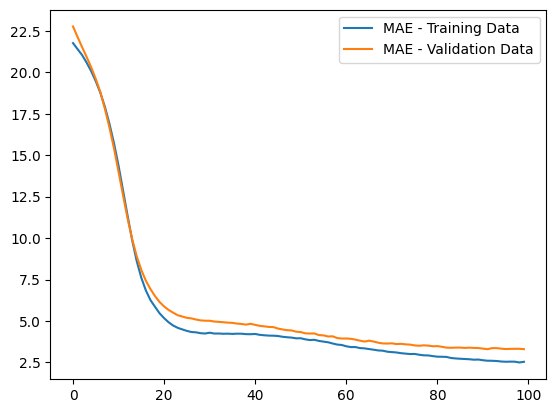

In [51]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history.history['mae'], label='MAE - Training Data')
plt.plot(history.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The training and validation MAEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge after 18 epochs.  They don't flatten as much as the ReLU activation but rather, seem to continue to drop.

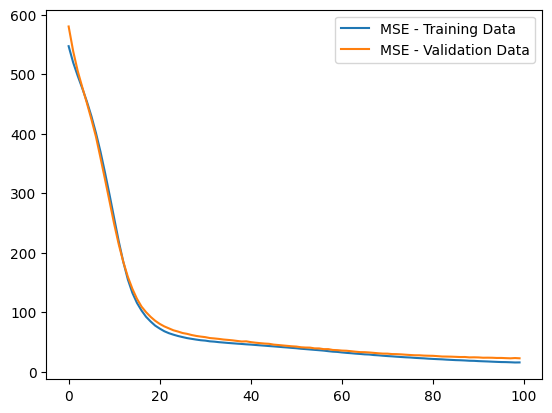

In [52]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history.history['loss'], label='MSE - Training Data')
plt.plot(history.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

The training and validation MSEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge after 18 epochs.  They seem to very closely match.  Therefore, the learning model seems to be generalizing very well.

## d) Model 4 [2 points]

- Same as Model 2, but use the rmsprop optimizer when training.

In [53]:
# Set the number of folds / splits.

the_splits = 3

# Create the cross-fold object.

kf = KFold(n_splits=the_splits, shuffle=True, random_state=42)

# Initialize the Mean Absolute Error array.

mae_scores = []

# Create the cross-validation on the training data.

for train_idx, valid_idx in kf.split(X_train_full):

    X_train, X_valid = X_train_full.iloc[train_idx], X_train_full.iloc[valid_idx]
    y_train, y_valid = y_train_full.iloc[train_idx, -1], y_train_full.iloc[valid_idx, -1]

    # Use the standard scaler to scale the features.  Just fit on the training data to train
    # the model and prevent data leakage into the model.
    #
    # Don't fit on the valid data as that needs to be independent to validate
    # and test the model.
    #
    # Don't include the test data as that would transform the data
    # multiple times in a cross-fold.

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # Create a 2 hidden layer neural net with 128 neurons in the first
    # hidden layer and 64 neurons in the second both using
    # the ReLU activation function.

    model = keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # Output layer for regression
    ])

    # Compile the model using the RMSprop optimizer with a learning rate of
    # the default, 0.001, telling the compiler to minimize the Minimum
    # Squared Error (MSE) loss value which is good for regression.
    #
    # Monitor the compilation using the Minimum Absolute Error
    # just for ease of monitoring and a more user-friendly way of
    # interpreting error.

    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Fit the model using the training features (X_train), training targets (y_train).
    # Validate the model with the validation data (X_valid, y_valid).

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    # Validate the model, calculate the MAE for this fold
    # and store it in the array.

    y_pred = model.predict(X_valid, verbose=0)
    kfold_mae = mean_absolute_error(y_valid, y_pred)
    mae_scores.append(kfold_mae)

# Calculate the overall MAE with standard deviation from the cross-validation.
# The MAE from cross-validation is based on the MAEs collected during each
# cross-validation fold.

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

print(f"MAE from cross-validation = {mean_mae:.3f} ± {std_mae:.3f}")


MAE from cross-validation = 2.743 ± 0.123


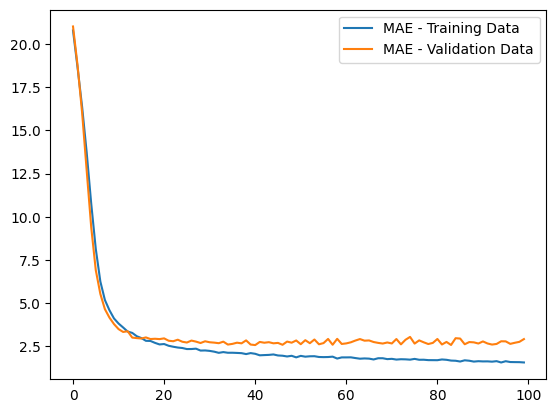

In [54]:
# Plot the Mean Absolute Error for the model training (over the epochs).

plt.plot(history.history['mae'], label='MAE - Training Data')
plt.plot(history.history['val_mae'], label='MAE - Validation Data')
plt.legend()
plt.show()

The training and validation MAEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge after 18 epochs. However, even though they flatten, relativelyi speaking, they seem to be a bit shaky.

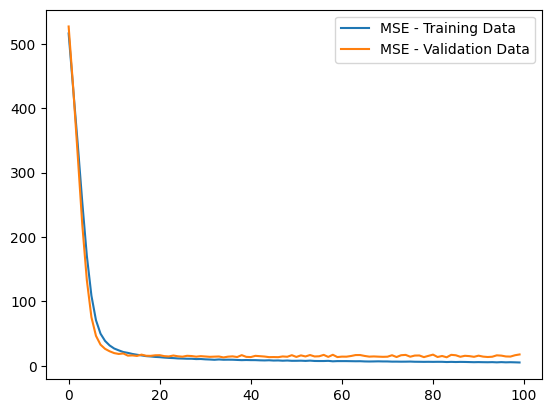

In [55]:
# Plot the Mean Squared Error for the model training (over the epochs).

plt.plot(history.history['loss'], label='MSE - Training Data')
plt.plot(history.history['val_loss'], label='MSE - Validation Data')
plt.legend()
plt.show()

The training and validation MSEs seems to quickly drop over the first 15 epochs in the initial stages of learning and converge after 18 epochs. They seem to very closely match. Therefore, the learning model seems to be generalizing very well.

## e) Model Comparison [1 point]

Which model performed best? Offer your thoughts on why the particular choice of hyperparameters led to improved performance for this model.

In [56]:
# explain WHY you think the best model was better than the rest, in terms
# of how those hyperparameters theoretically impact the model

# provide visualizations (e.g. tables or comparison plot) to support your response where possible

The hyperparameters that were changed between Models were:

*   Activation Function (ReLU vs tanh)
*   Number of neurons in the hidden layers (128 vs 64)
*   Compilation optimizer (ADAM vs RMSprop)

The MAE from cross-validation with standard deviation for each model is:

Model / MAE (may vary in different runs):

1.   2.644 ± 0.031
2.   2.660 ± 0.074
3.   3.220 ± 0.206
4.   2.611 ± 0.089

Models 1, 2 and 4 are very similar.  

Model 3 appears to perform the worst.  Therefore, using the tanh activation function in Model 3 may not be the best choice.  The ReLu activation function seems to provide better performance than the tanh as it seems to learn faster.  It provides faster convergence between the training and validation data especially for regression problems.  Model 3, with a higher MAE and a higher standard deviation, is the least accurate and least stable.

From an MAE perspective, Model 4 is the most accurate as it has the lowest mean average error.  However, Model 4 has a higher standard deviation than Model 1.  The higher the standard deviation, the more unstable the model is. This can be seen by the MAE / MSE plots above when the training and validation graphs flatten and converge.  Therefore, Model 4 is the most accurate but Model 1 is the most stable.

However, when both MAE and standard deviation are considered, Model 1 seems to be the best choice (64 neurons in each layer, ReLU activation function and ADAM optimizer).

As a future experiment, the number of epochs can be increased to see if that changes any of the MAE / standard deviation numbers.










NOTE: 2 additional points are awarded based on code documentation and overall clarity of work.

In [57]:
# We are looking for a clear explanation of results with each response. We want you to attempt to
# explain the _how_ and _why_ behind your answers, and not just the what, do demonstrate
# your knowledge of the concepts discussed in class. Answers should be backed up with
# visualizations (e.g. plots, charts).

# Code should be easy to follow by using sensical naming conventions for function and variable
# names, providing useful code comments, and refactoring repeated code into re-usable functions.